# Plot Batch Experiment for Several Values of alpha

In [1]:
import pickle
from pathlib import Path

In [2]:
with open("../scripts/aggregated_final_draft_100.pkl","rb",) as f: #TODO: change if needed
    results_all = pickle.load(f)

Important: filter on specific values

In [3]:
std_val = 0.15 # TODO: CHANGE HERE

results = {
    k[1]: v
    for k, v in results_all.items()
    if k[0] == std_val
}

plot_dir = Path("../plots_final_draft_100/std015") # TODO: CHANGE HERE

In [4]:
print(results[1].keys())

dict_keys([<PropertyEnum.AVERAGE_DEGREE: 12>, <PropertyEnum.AVERAGE_DEGREE_PER_LAYER: 13>, <PropertyEnum.DENSITY: 8>, <PropertyEnum.DENSITY_PER_LAYER: 9>, <PropertyEnum.AVERAGE_LOCAL_CLUSTERING: 11>, <PropertyEnum.DEGREE_DISTRIBUTION: 1>, <PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER: 2>, <PropertyEnum.TRIANGLES: 14>, <PropertyEnum.TRIANGLES_PER_LAYER: 15>, <PropertyEnum.TRIANGLE_DIMENSIONS: 16>, <PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION: 4>, <PropertyEnum.GLOBAL_CLUSTERING: 10>, <PropertyEnum.EDGE_LENGTH_DISTRIBUTION: 5>, <PropertyEnum.AVERAGE_ALTER_DISTANCE_DISTRIBUTION: 6>, <PropertyEnum.AVERAGE_MULTIPLEXITY: 17>])


### Property Analysis

In [5]:
alpha_list = [(1/2)**(i) for i in range(0, 11)]
layer_sizes = [656, 4700, 326, 7962, 5817] # CHANGE HERE
layer_labels = ["L1", "L2", "L3", "L4", "L5"]
layer_colors = ["blue", "red", "gold", "green", "grey"]

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as clr
import numpy as np

alphas = alpha_list
linestyles = ["-"]

cmap = cm.viridis

norm = clr.SymLogNorm(
    linthresh=1e-3,
    vmin=min(alphas),
    vmax=max(alphas),
    base=2,
)

tick_is = list(range(0, 21, 2))
ticks = [(1/2)**(i/2) for i in tick_is]

log_ticks = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

In [7]:
from msean.measurements.properties import PropertyEnum

prop_labels = {
    PropertyEnum.TRIANGLES: r"Number of triangles ($\tau$)",
    PropertyEnum.TRIANGLES_PER_LAYER: r"Number of triangles for layer ($\tau^\ell$)",
    PropertyEnum.AVERAGE_DEGREE: r"Average degree ($\kappa$)",
    PropertyEnum.AVERAGE_DEGREE_PER_LAYER: r"Average degree for layer ($\kappa^\ell$)",
    PropertyEnum.DENSITY: r"Density ($\rho$)",
    PropertyEnum.DENSITY_PER_LAYER: r"Density for layer ($\rho^\ell$)",
    PropertyEnum.DEGREE_DISTRIBUTION: rf"Degree ($\mathit{{k}}$)",
    PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER: rf"Degree ($\mathit{{k}}$)",
    PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION: rf"Local clustering coefficient ($\mathit{{c}}$)",
    PropertyEnum.AVERAGE_LOCAL_CLUSTERING: rf"Average clustering coefficient ($\bar{{c}}$)",
    PropertyEnum.GLOBAL_CLUSTERING: rf"Global clustering coefficient ($\mathit{{C}}$)",
    PropertyEnum.EDGE_LENGTH_DISTRIBUTION: "Edge length",
    PropertyEnum.AVERAGE_ALTER_DISTANCE_DISTRIBUTION: "Average alter distance",
    PropertyEnum.AVERAGE_MULTIPLEXITY: "Share of multiplex ties"
}

alpha_label = r"Spatial freedom ($\alpha$)"

### Global Scalar Properties

average_degree vs alpha


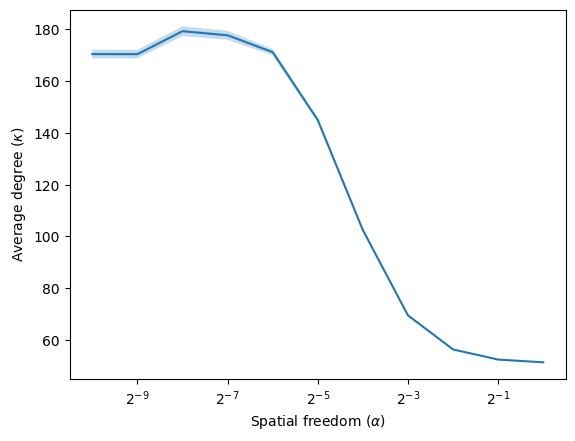

density vs alpha


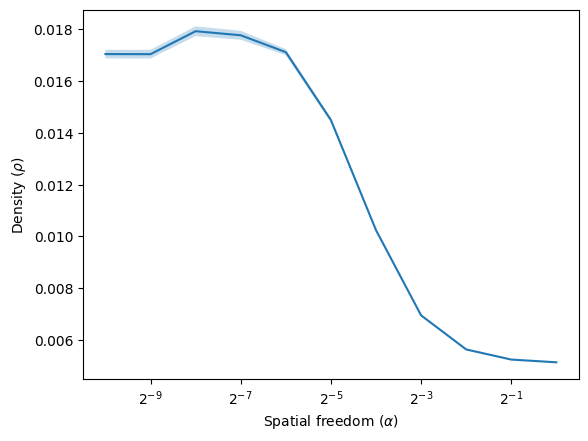

average_local_clustering vs alpha


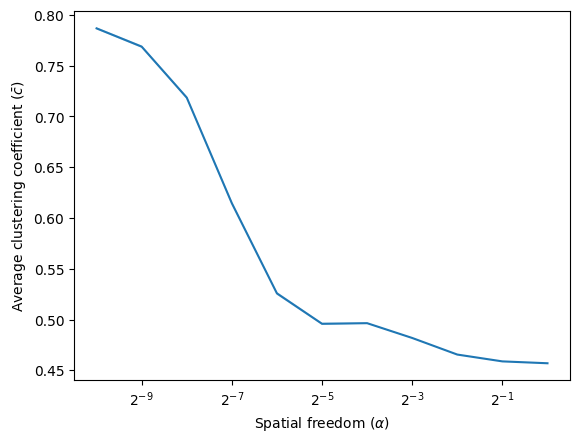

global_clustering vs alpha


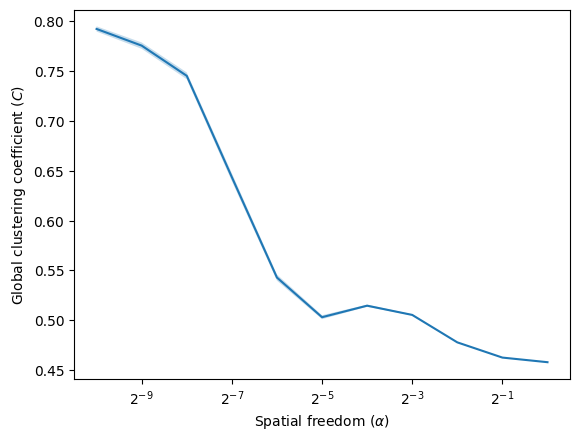

triangles vs alpha


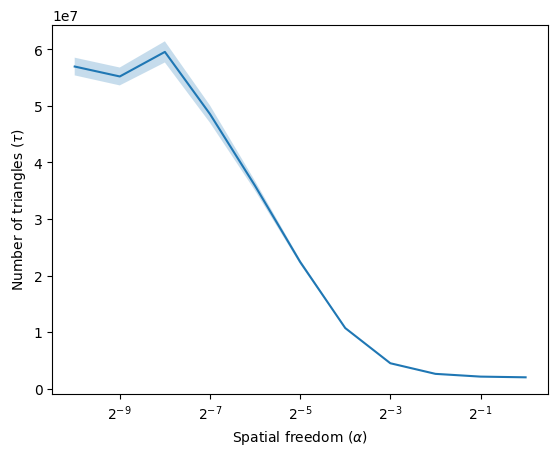

average_multiplexity vs alpha


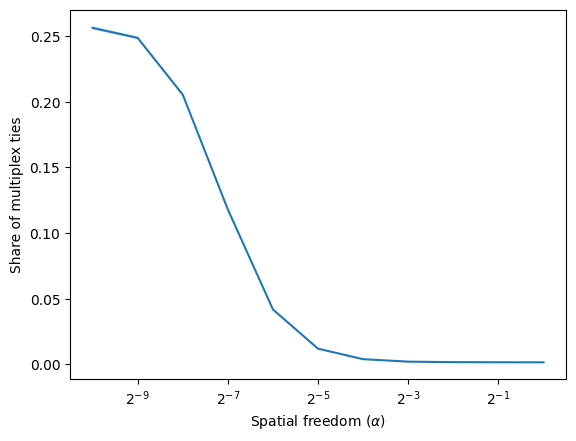

In [8]:
global_props = [
    PropertyEnum.AVERAGE_DEGREE,
    PropertyEnum.DENSITY,
    PropertyEnum.AVERAGE_LOCAL_CLUSTERING,
    PropertyEnum.GLOBAL_CLUSTERING,
    PropertyEnum.TRIANGLES,
    PropertyEnum.AVERAGE_MULTIPLEXITY
]

for prop in global_props:
    print(f"{prop.name.lower()} vs alpha")

    means = np.array([results[a][prop][0] for a in alphas])
    #stds = np.array([results[a][prop][1] for a in alphas])
    ses = np.array([results[a][prop][2] for a in alphas])

    fig, ax = plt.subplots()

    ax.plot(alphas, means)

    ax.fill_between(
        alphas,
        means - ses, #stds,
        means + ses, #stds,
        alpha=0.25,
    )

    ax.set_xscale("log", base=2)
    ax.set_xlabel(alpha_label)

    label = prop_labels.get(prop, prop.name.lower())
    ax.set_ylabel(label)

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_vs_alpha-log.png",
        bbox_inches="tight",
    )

    plt.show()

In [9]:
# Will be used in closure plots
share_multiplex_ties_list = np.array([results[a][PropertyEnum.AVERAGE_MULTIPLEXITY][0] for a in alphas])
print(share_multiplex_ties_list)

[0.00139038 0.00142012 0.00150862 0.0018951  0.00378902 0.01178186
 0.0416648  0.11789153 0.20536616 0.24863252 0.25624445]


### Per-layer Global Properties

average_degree_per_layer vs alpha


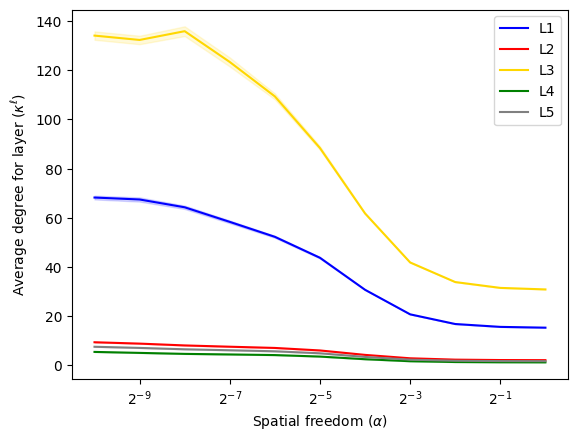

density_per_layer vs alpha


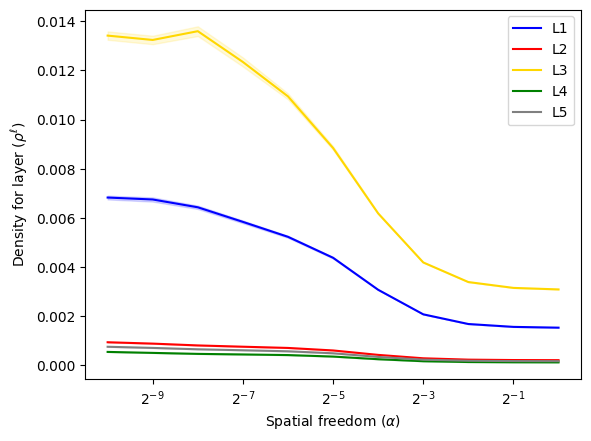

triangles_per_layer vs alpha


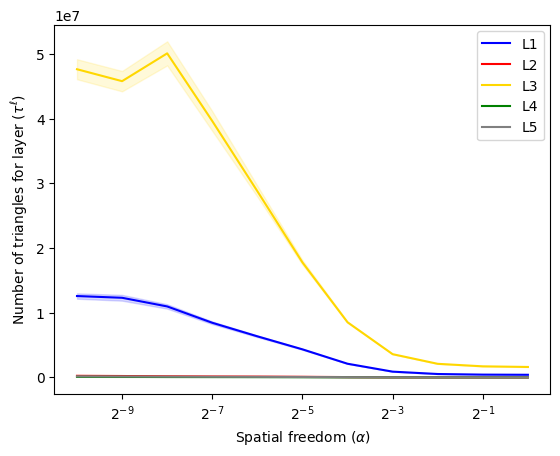

In [10]:
per_layer_props = [
    PropertyEnum.AVERAGE_DEGREE_PER_LAYER,
    PropertyEnum.DENSITY_PER_LAYER,
    PropertyEnum.TRIANGLES_PER_LAYER
]

for prop in per_layer_props:
    print(f"{prop.name.lower()} vs alpha")

    fig, ax = plt.subplots()

    for j, label in enumerate(layer_labels):

        means = np.array([results[a][prop][0][j] for a in alphas])
        #stds = np.array([results[a][prop][1][j] for a in alphas])
        ses = np.array([results[a][prop][2][j] for a in alphas])

        ax.plot(
            alphas,
            means,
            color=layer_colors[j],
            linestyle=linestyles[j % len(linestyles)],
            label=label,
        )

        ax.fill_between(
            alphas,
            means - ses, #stds,
            means + ses, #stds,
            color=layer_colors[j],
            alpha=0.15,
        )

    #ax.set_title(f"{label} vs {alpha_label} by layer")
    ax.set_xscale("log", base=2)
    ax.set_xlabel(alpha_label)
    
    label = prop_labels.get(prop, prop.name.lower())
    ax.set_ylabel(label)

    ax.legend()

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_vs_alpha_by_layer_log.png",
        bbox_inches="tight",
    )

    plt.show()

### Distribution Properties

In [11]:
def rebin_degree_distribution(x, y, se, bin_width=5):
    x = np.asarray(x)
    y = np.asarray(y)
    se = np.asarray(se)

    bin_id = (x // bin_width).astype(int)

    x_binned = []
    y_binned = []
    se_binned = []

    for b in np.unique(bin_id):
        mask = bin_id == b

        x_binned.append(np.mean(x[mask]))
        y_binned.append(np.nansum(y[mask]))
        se_binned.append(np.sqrt(np.nansum(se[mask] ** 2)))

    return np.array(x_binned), np.array(y_binned), np.array(se_binned)

degree_distribution across alpha values


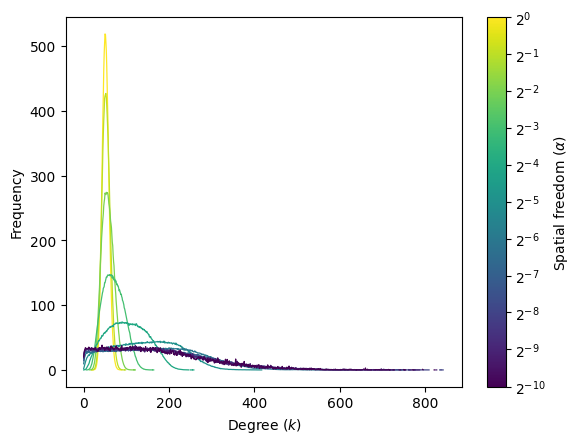

local_clustering_distribution across alpha values


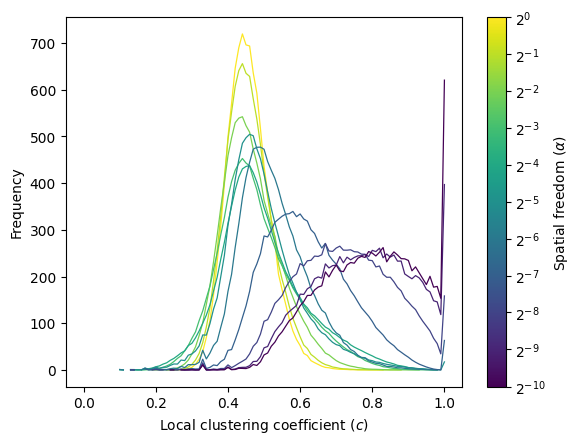

edge_length_distribution across alpha values


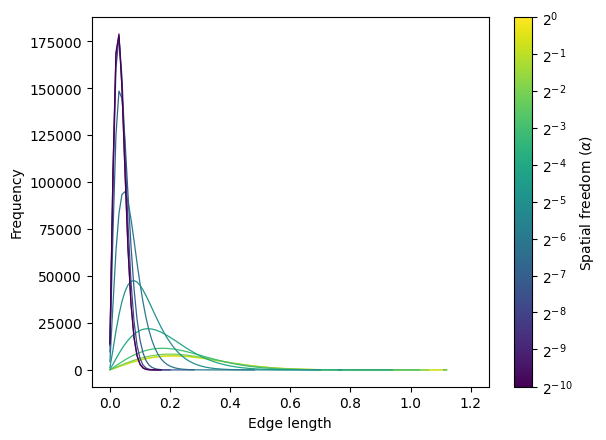

average_alter_distance_distribution across alpha values


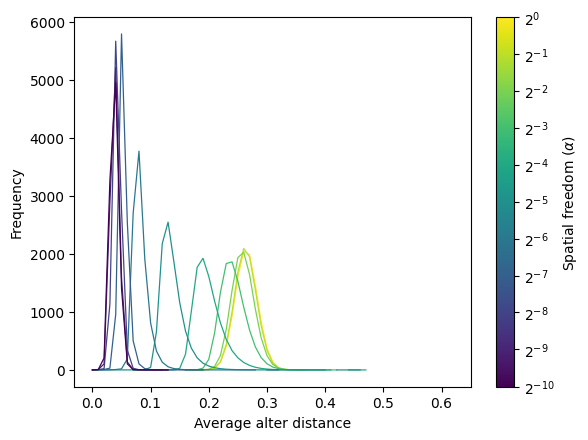

In [12]:
distribution_props = [
    PropertyEnum.DEGREE_DISTRIBUTION,
    PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION,
    PropertyEnum.EDGE_LENGTH_DISTRIBUTION,
    PropertyEnum.AVERAGE_ALTER_DISTANCE_DISTRIBUTION
]

for prop in distribution_props:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):
        dist = results[alpha][prop]

        x = dist[:, 0]
        y = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = y - se
        upper = y + se

        y[y <= 0] = np.nan
        lower[lower <= 0] = 0
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9,
        )

        """ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(alpha_label)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([
        rf"$2^{{{-i//2}}}$"
        for i in tick_is
    ])

    label = prop_labels.get(prop, prop.name.lower())

    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

average_alter_distance_distribution across alpha values


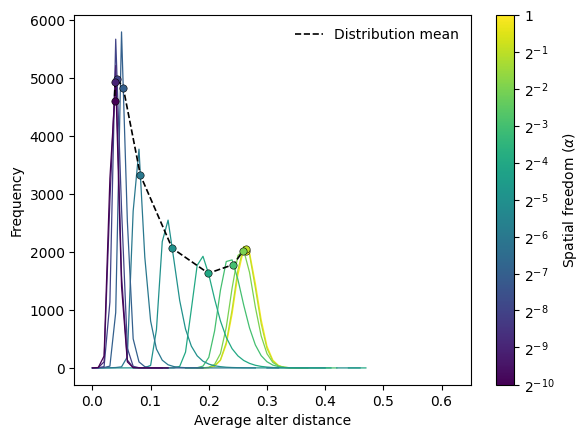

In [13]:
prop = PropertyEnum.AVERAGE_ALTER_DISTANCE_DISTRIBUTION

print(f"{prop.name.lower()} across alpha values")

fig, ax = plt.subplots()

mean_points_x = []
mean_points_y = []

for i, alpha in enumerate(alphas):

    dist = results[alpha][prop]

    x = dist[:, 0].astype(float)
    y = dist[:, 1].astype(float)
    se = dist[:, 3].astype(float)

    # Weighted mean of the distribution
    mean_x = np.sum(x * y) / np.sum(y)

    # Frequency at the mean (interpolated)
    mean_y = np.interp(mean_x, x, y)

    mean_points_x.append(mean_x)
    mean_points_y.append(mean_y)

    lower = y - se
    upper = y + se

    y[y <= 0] = np.nan
    lower[lower <= 0] = np.nan
    upper[upper <= 0] = np.nan

    color = cmap(norm(alpha))

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )

    # Mark the mean of this distribution
    ax.scatter(
        mean_x,
        mean_y,
        color=color,
        s=28,
        edgecolor="black",
        linewidth=0.4,
        zorder=4,
    )

# Connect the means
ax.plot(
    mean_points_x,
    mean_points_y,
    "--",
    color="black",
    linewidth=1.2,
    label="Distribution mean",
    zorder=3,
)

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    "1" if i == 0 else rf"$2^{{{-i//2}}}$"
    for i in tick_is
])

ax.legend(frameon=False)

label = prop_labels.get(prop, prop.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Frequency")

plt.savefig(
    plot_dir / f"{prop.name.lower()}_with_means.png",
    bbox_inches="tight",
)

plt.show()

degree_distribution across alpha values


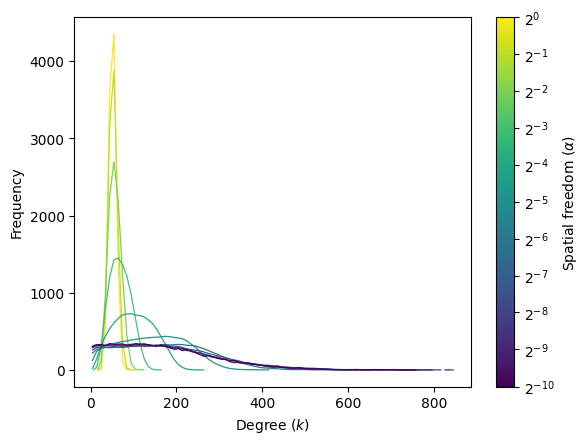

In [14]:
print(f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()} across alpha values")

fig, ax = plt.subplots()

for i, alpha in enumerate(alphas):
    dist = results[alpha][PropertyEnum.DEGREE_DISTRIBUTION]

    x = dist[:, 0]
    y = dist[:, 1].astype(float)
    se = dist[:, 3].astype(float)

    x, y, se = rebin_degree_distribution(
        x,
        y,
        se,
        bin_width=10,
    )

    lower = y - se
    upper = y + se

    y[y <= 0] = np.nan
    lower[lower <= 0] = 0
    upper[upper <= 0] = np.nan

    color = cmap(norm(alpha))

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    rf"$2^{{{-i//2}}}$"
    for i in tick_is
])

label = prop_labels.get(PropertyEnum.DEGREE_DISTRIBUTION, PropertyEnum.DEGREE_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Frequency")

plt.savefig(
    plot_dir / f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()}_all_alpha_binned_10_emph.png",
    bbox_inches="tight",
)

plt.show()

degree_distribution across alpha values


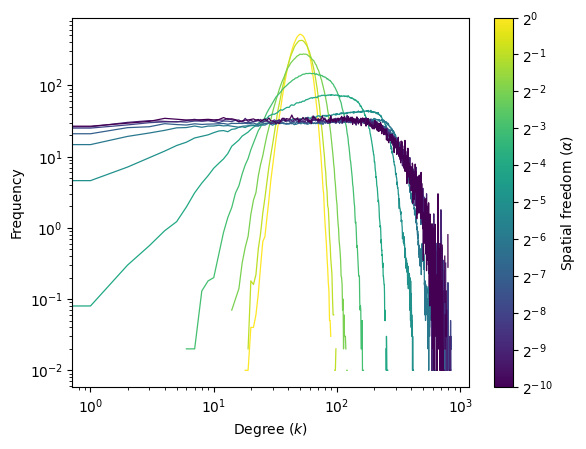

In [15]:
print(f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()} across alpha values")

fig, ax = plt.subplots()

for i, alpha in enumerate(alphas):
    dist = results[alpha][PropertyEnum.DEGREE_DISTRIBUTION]

    x = dist[:, 0]
    y = dist[:, 1].astype(float)
    se = dist[:, 3].astype(float)

    lower = y - se
    upper = y + se

    y[y <= 0] = np.nan
    lower[lower <= 0] = 0
    upper[upper <= 0] = np.nan

    color = cmap(norm(alpha))

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    rf"$2^{{{-i//2}}}$"
    for i in tick_is
])

label = prop_labels.get(PropertyEnum.DEGREE_DISTRIBUTION, PropertyEnum.DEGREE_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")

plt.savefig(
    plot_dir / f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()}_all_alpha_log.png",
    bbox_inches="tight",
)

plt.show()

degree_distribution across alpha values


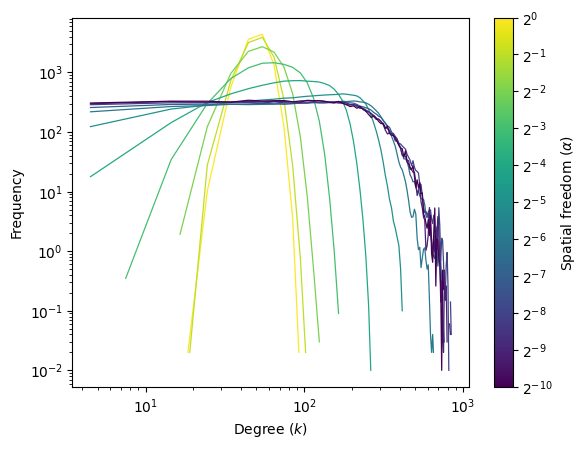

In [16]:
print(f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()} across alpha values")

fig, ax = plt.subplots()

for i, alpha in enumerate(alphas):
    dist = results[alpha][PropertyEnum.DEGREE_DISTRIBUTION]

    x = dist[:, 0]
    y = dist[:, 1].astype(float)
    se = dist[:, 3].astype(float)

    x, y, se = rebin_degree_distribution(
        x,
        y,
        se,
        bin_width=10,
    )

    lower = y - se
    upper = y + se

    y[y <= 0] = np.nan
    lower[lower <= 0] = 0
    upper[upper <= 0] = np.nan

    color = cmap(norm(alpha))

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    rf"$2^{{{-i//2}}}$"
    for i in tick_is
])

label = prop_labels.get(PropertyEnum.DEGREE_DISTRIBUTION, PropertyEnum.DEGREE_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")

plt.savefig(
    plot_dir / f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()}_all_alpha_log_binned_10.png",
    bbox_inches="tight",
)

plt.show()

degree_distribution across alpha values


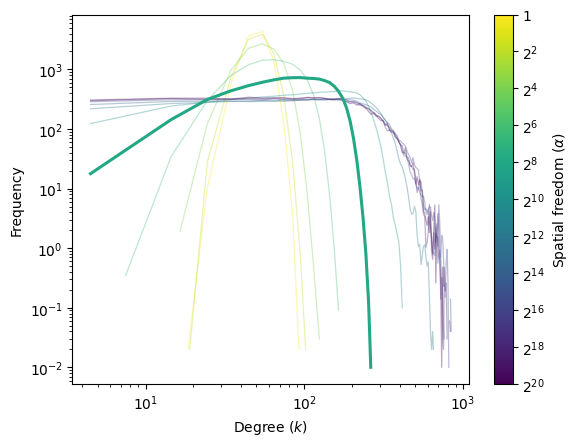

In [17]:
print(f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()} across alpha values")

highlight_idx = 4  # alpha = 2^-4

fig, ax = plt.subplots()

for i, alpha in enumerate(alphas):
    dist = results[alpha][PropertyEnum.DEGREE_DISTRIBUTION]

    x = dist[:, 0]
    y = dist[:, 1].astype(float)
    se = dist[:, 3].astype(float)

    x, y, se = rebin_degree_distribution(
        x,
        y,
        se,
        bin_width=10,
    )

    lower = y - se
    upper = y + se

    y[y <= 0] = np.nan
    lower[lower <= 0] = 0
    upper[upper <= 0] = np.nan

    color = cmap(norm(alpha))

    highlight = (i == highlight_idx)

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.2 if highlight else 0.9,
        alpha=1.0 if highlight else 0.35,
        zorder=3 if highlight else 1,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    "1" if exponent == 0 else rf"$2^{{{exponent}}}$"
    for exponent in tick_is
])

label = prop_labels.get(PropertyEnum.DEGREE_DISTRIBUTION, PropertyEnum.DEGREE_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")

plt.savefig(
    plot_dir / f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()}_all_alpha_log_binned_10_emph.png",
    bbox_inches="tight",
)

plt.show()

degree_distribution across alpha values


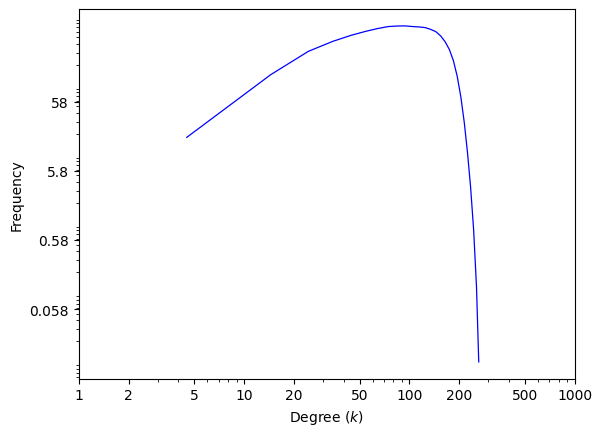

In [18]:
print(f"{PropertyEnum.DEGREE_DISTRIBUTION.name.lower()} across alpha values")
log_ticks = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

fig, ax = plt.subplots()

dist = results[2**(-4)][PropertyEnum.DEGREE_DISTRIBUTION]

x = dist[:, 0]
y = dist[:, 1].astype(float)
se = dist[:, 3].astype(float)

x, y, se = rebin_degree_distribution(
    x,
    y,
    se,
    bin_width=10,
)

lower = y - se
upper = y + se

y[y <= 0] = np.nan
lower[lower <= 0] = 0
upper[upper <= 0] = np.nan


ax.plot(
    x,
    y,
    color="blue",
    linestyle=linestyles[i % len(linestyles)],
    linewidth=0.9,
)

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

label = prop_labels.get(PropertyEnum.DEGREE_DISTRIBUTION, PropertyEnum.DEGREE_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(log_ticks)
ax.set_xticklabels(log_ticks)
ax.set_yticks([0.058, 0.58, 5.8, 58])
ax.set_yticklabels([0.058, 0.58, 5.8, 58])

plt.show()

### Edge Length Distribution Normalized

In [19]:
import math
from msean.config import Config, load_config

def sq_line_picking_prob(cfg:Config, delta):
    """
    Probability density function for the distance δ between two points chosen uniformly on the unit square.

    P(δ) = { 2δ (δ² - 4δ + 𝝅) if 0 ≤ δ ≤ 1,
           { 2δ (4√(δ² - 1) - (δ² + 2 - 𝝅) - 4tan⁻¹√(δ² -1)) if 1 ≤ δ ≤ √2
    """
    if delta <= 1:
        return 2*delta * (delta**2 - 4*delta + math.pi)
    else:
        return 2*delta * (4 * math.sqrt(delta**2 - 1) - (delta**2 + 2 - math.pi) - 4 * math.atan(math.sqrt(delta**2 - 1)))
    
def normalise_as_pdf(vals, bin_size):
    Z = 0
    for i in range(len(vals)):
        Z += vals[i] * bin_size

    return np.array([elem / Z for elem in vals])

edge_length_distribution across alpha values, normalized


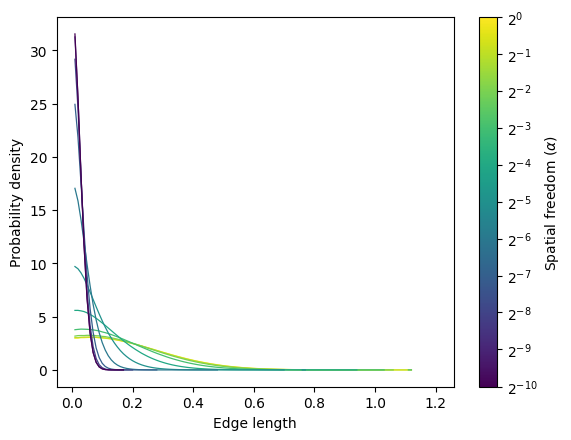

In [20]:
print(f"{PropertyEnum.EDGE_LENGTH_DISTRIBUTION.name.lower()} across alpha values, normalized")

root = Path.cwd().parents[0]
cfg = load_config(root / "configs" / "default_server.yaml")

fig, ax = plt.subplots()

for i, alpha in enumerate(alphas):
    dist = results[alpha][PropertyEnum.EDGE_LENGTH_DISTRIBUTION]

    x = dist[:, 0]
    y = dist[:, 1].astype(float)

    prob = np.array([
        sq_line_picking_prob(cfg, delta)
        for delta in x
    ])

    mask = prob > 1e-3 # Avoiding cases with division by 0

    x = x[mask]
    y = y[mask] / prob[mask]
    y = normalise_as_pdf(y, 0.01)

    y[y <= 0] = np.nan

    color = cmap(norm(alpha))

    ax.plot(
        x,
        y,
        color=color,
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(alpha_label)
cbar.set_ticks(ticks)
cbar.set_ticklabels([
    rf"$2^{{{-i//2}}}$"
    for i in tick_is
])

label = prop_labels.get(PropertyEnum.EDGE_LENGTH_DISTRIBUTION, PropertyEnum.EDGE_LENGTH_DISTRIBUTION.name.lower())

ax.set_xlabel(label)
ax.set_ylabel("Probability density")

plt.savefig(
    plot_dir / f"{PropertyEnum.EDGE_LENGTH_DISTRIBUTION.name.lower()}_all_alpha_normalized.png",
    bbox_inches="tight",
)

plt.show()

### Average Alter Distance

average edge length vs alpha


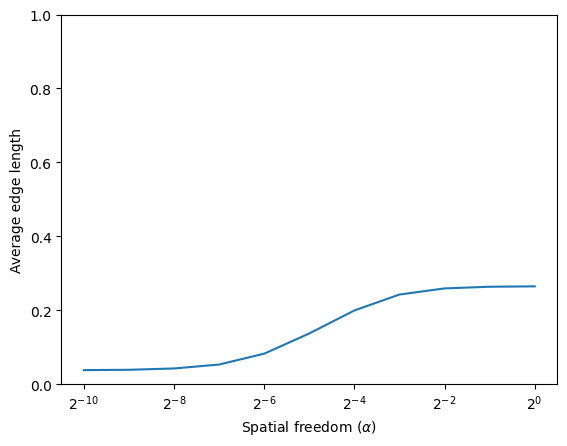

In [21]:
print("average edge length vs alpha")

means = []
ses = []

for alpha in alphas:

    dist = results[alpha][PropertyEnum.AVERAGE_ALTER_DISTANCE_DISTRIBUTION]

    x = dist[:, 0]
    freq = dist[:, 1].astype(float)
    se = dist[:, 3].astype(float)

    # Normalize frequencies to sum to 1
    freq = freq / np.sum(freq)

    mean = np.sum(x * freq)

    # Approximate error propagation
    se_mean = np.sqrt(np.sum((x * se) ** 2))

    means.append(mean)
    ses.append(se_mean)

means = np.array(means)
ses = np.array(ses)

fig, ax = plt.subplots()

ax.plot(
    alphas,
    means,
    linewidth=1.5,
)

"""ax.fill_between(
    alphas,
    means - ses,
    means + ses,
    alpha=0.2,
)
"""
# Sensitive y-axis
y_min = np.nanmin(means - ses)
y_max = np.nanmax(means + ses)
pad = 0.05 * (y_max - y_min)

ax.set_ylim(
    max(0, y_min - pad),
    min(1, y_max + pad),
)

ax.set_xscale("log", base=2)

tick_exponents = np.arange(-10, 1, 2)
ax.set_xticks(2.0 ** tick_exponents)
ax.set_xticklabels([
    rf"$2^{{{i}}}$"
    for i in tick_exponents
])

ax.set_xlabel(alpha_label)
ax.set_ylabel("Average edge length")

plt.savefig(
    plot_dir / "average_edge_length_vs_alpha.png",
    bbox_inches="tight",
)

plt.show()

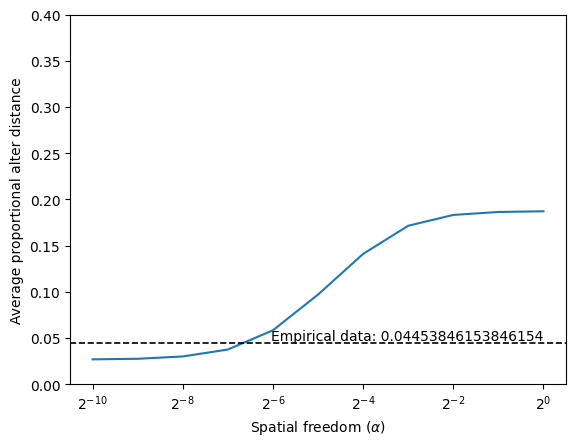

In [22]:
means_norm = means / np.sqrt(2)
ses_norm = ses / np.sqrt(2)

emp_mean = 13.896/312

fig, ax = plt.subplots()

ax.plot(
    alphas,
    means_norm,
    linewidth=1.5,
)

"""ax.fill_between(
    alphas,
    means_norm - ses_norm,
    means_norm + ses_norm,
    alpha=0.2,
)"""

ax.set_xscale("log", base=2)

tick_exponents = np.arange(-10, 1, 2)
ax.set_xticks(2.0 ** tick_exponents)
ax.set_xticklabels([
    rf"$2^{{{i}}}$"
    for i in tick_exponents
])

# Sensitive y-axis
y_min = np.nanmin(means_norm - ses_norm)
y_max = np.nanmax(means_norm + ses_norm)
pad = 0.05 * (y_max - y_min)

ax.set_ylim(
    max(0, y_min - pad),
    0.4,
)

ax.axhline(
    emp_mean,
    color="black",
    linestyle="--",
    linewidth=1.2,
)

ax.text(
    1,
    emp_mean,
    f"Empirical data: {emp_mean}",
    va="bottom",
    ha="right",
    fontsize=10,
)

ax.set_xlabel(alpha_label)
ax.set_ylabel(r"Average proportional alter distance")

plt.savefig(
    plot_dir / "average_edge_length_over_sqrt2_vs_alpha.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [23]:
# Will be used in closure plots
avg_prop_alter_dist = means
avg_prop_alter_dist_ses = ses
print(avg_prop_alter_dist)

[0.26452753 0.26347582 0.25897148 0.24237774 0.19930223 0.13706881
 0.08240926 0.05295076 0.04235664 0.03877893 0.03792006]


average_alter_distance_distribution across alpha values


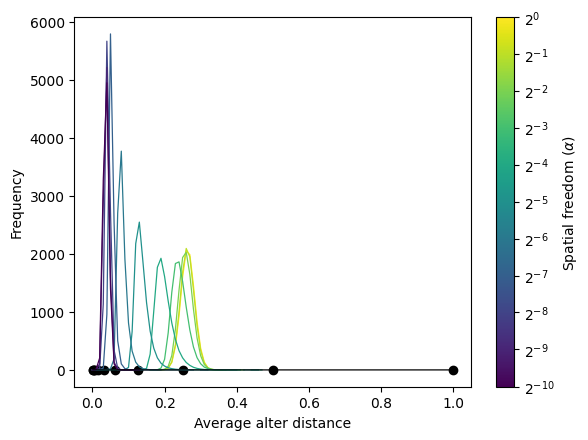

In [24]:
# TODO: fix this

distribution_props = [
    PropertyEnum.AVERAGE_ALTER_DISTANCE_DISTRIBUTION
]

for prop in distribution_props:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):
        dist = results[alpha][prop]

        x = dist[:, 0]
        y = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = y - se
        upper = y + se

        y[y <= 0] = np.nan
        lower[lower <= 0] = 0
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9,
        )

        """ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    ax.plot(
        alphas,
        avg_prop_alter_dist,
        color="black",
        linestyle=linestyles[i % len(linestyles)],
        linewidth=0.9,
    )
    ax.scatter(
        alphas,
        avg_prop_alter_dist,
        color="black"
    )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(alpha_label)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([
        rf"$2^{{{-i//2}}}$"
        for i in tick_is
    ])

    label = prop_labels.get(prop, prop.name.lower())

    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

### Degree Distribution Per Layer

degree_distribution for layer L1 (656) across alpha


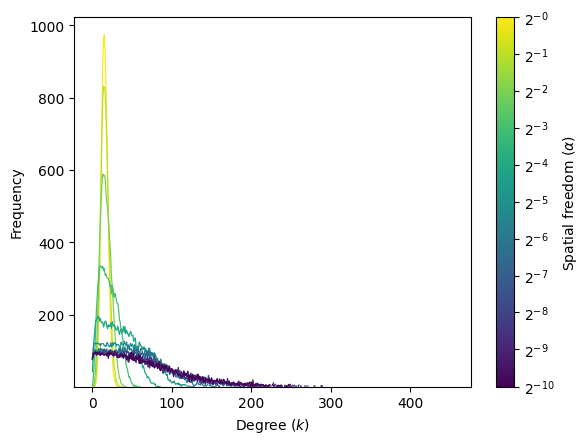

degree_distribution for layer L2 (4700) across alpha


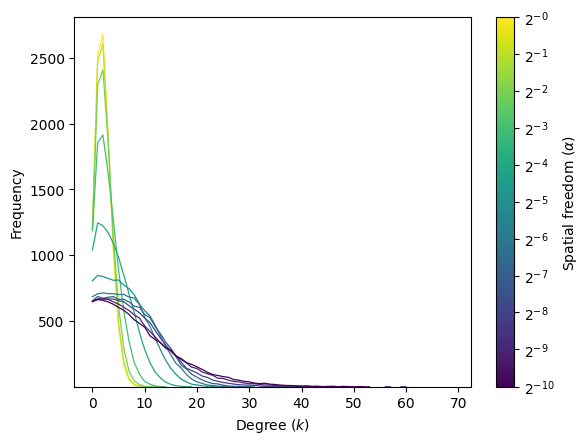

degree_distribution for layer L3 (326) across alpha


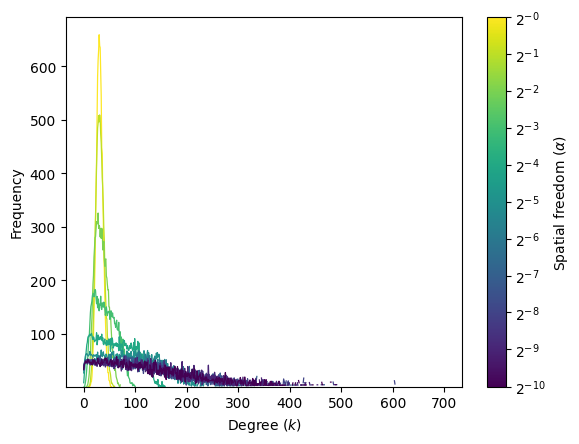

degree_distribution for layer L4 (7962) across alpha


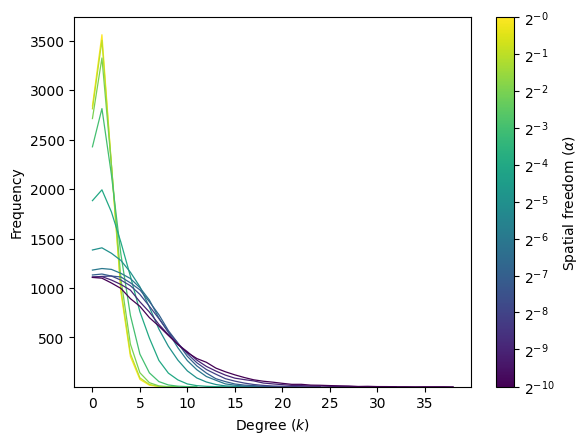

degree_distribution for layer L5 (5817) across alpha


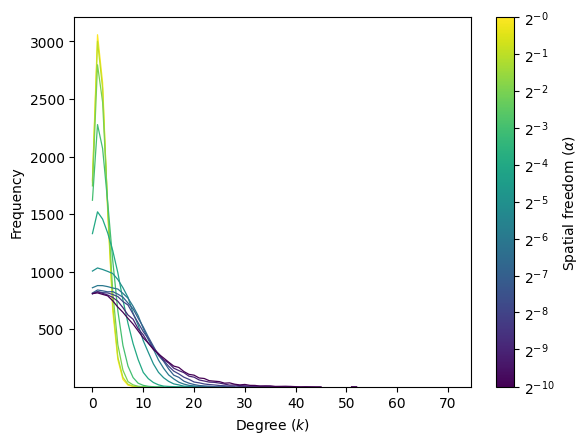

In [25]:
for layer_idx, layer_label in enumerate(layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9
        )

        """ax.fill_between(
            k,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 21, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    ax.set_ylim(bottom=1)

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer L1 (656) across alpha


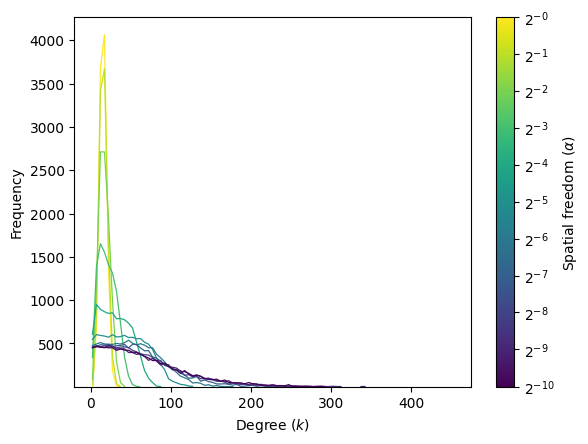

degree_distribution for layer L2 (4700) across alpha


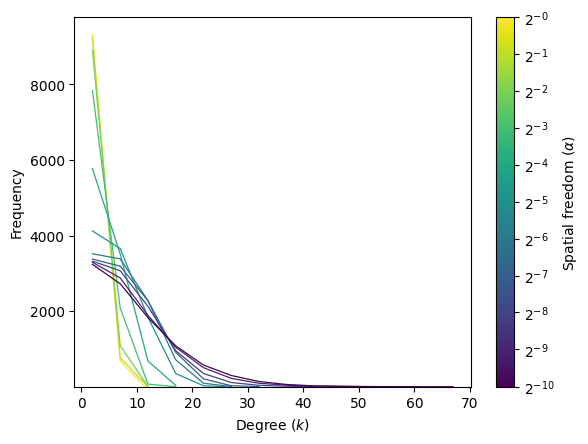

degree_distribution for layer L3 (326) across alpha


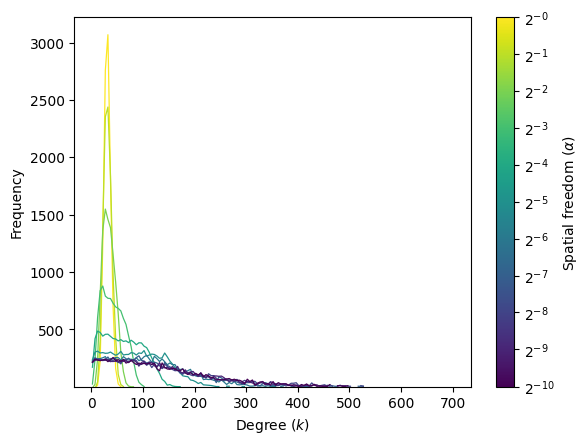

degree_distribution for layer L4 (7962) across alpha


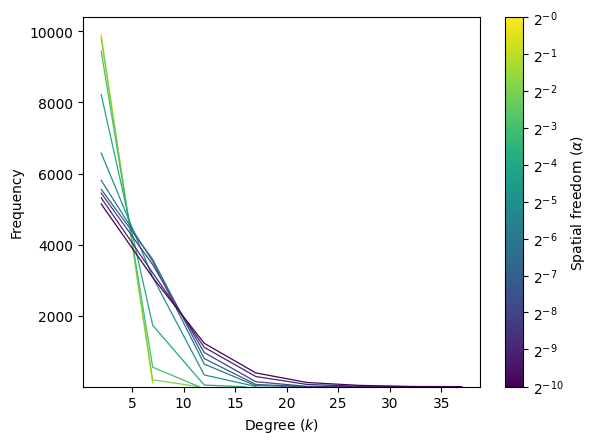

degree_distribution for layer L5 (5817) across alpha


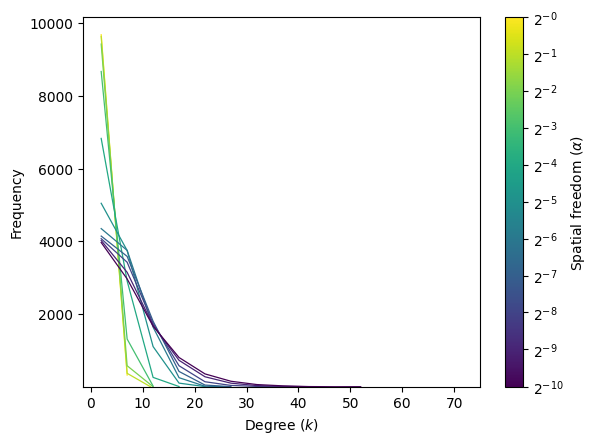

In [26]:
for layer_idx, layer_label in enumerate(layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        x, y, se = rebin_degree_distribution(
            k,
            freq,
            se,
            bin_width=5,
        )

        lower = y - se
        upper = y + se

        y[y <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 21, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    ax.set_ylim(bottom=1)

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha_binned_5.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer L1 (656) across alpha


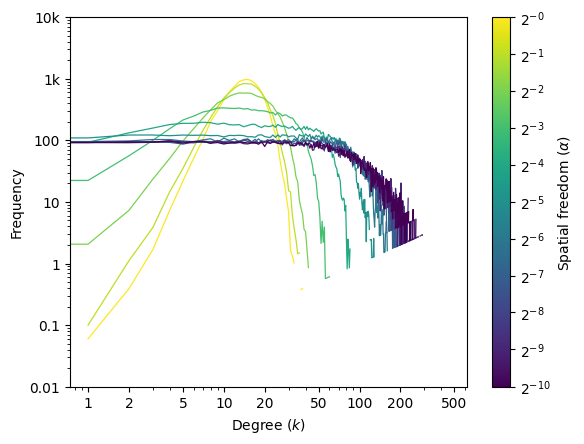

degree_distribution for layer L2 (4700) across alpha


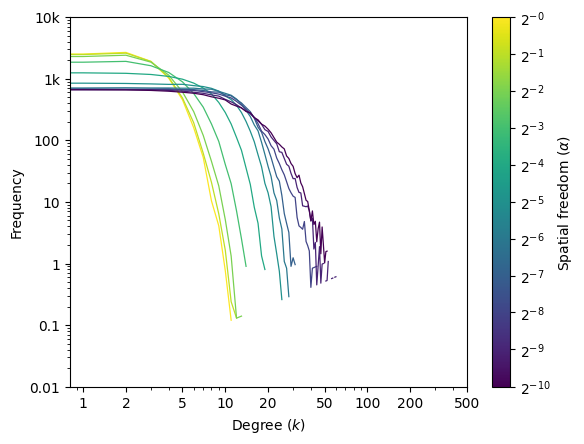

degree_distribution for layer L3 (326) across alpha


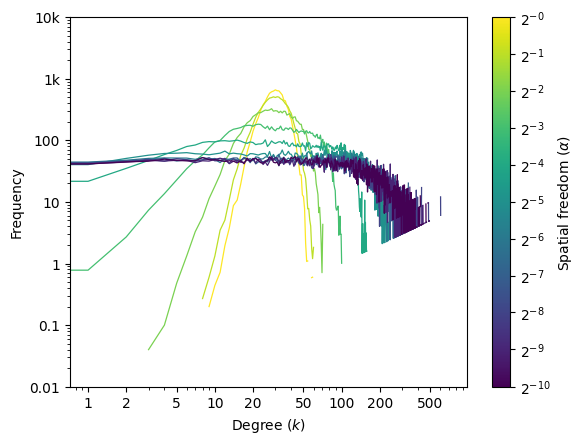

degree_distribution for layer L4 (7962) across alpha


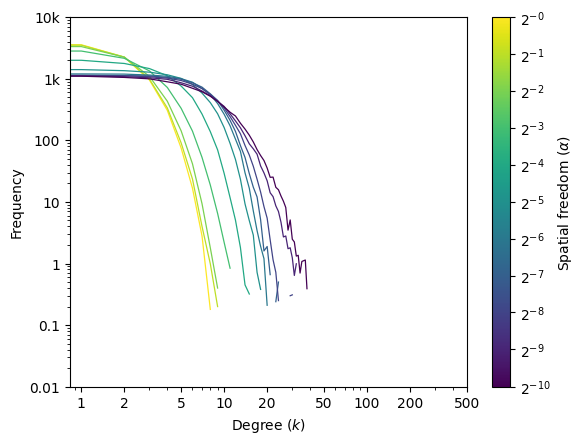

degree_distribution for layer L5 (5817) across alpha


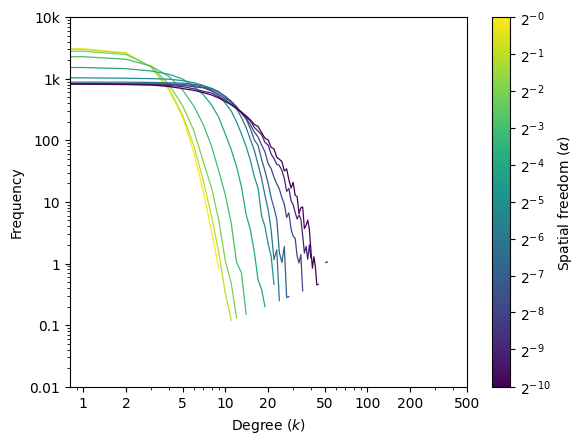

In [27]:
yticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
ytick_labels = ["0.01", "0.1", "1", "10", "100", "1k", "10k"]
xticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]

for layer_idx, layer_label in enumerate(layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9
        )

        """ax.fill_between(
            k,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j//2}}}$"
        for j in range(0, 21, 2)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")

    ax.set_xscale("log")
    ax.set_yscale("log")
    #ax.set_ylim(1, plt.ylim()[1])
    #ax.set_xlim(1, plt.ylim()[1])

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([str(t) for t in xticks])
    ax.set_yticklabels(ytick_labels)

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha_log.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer L1 (656) across alpha


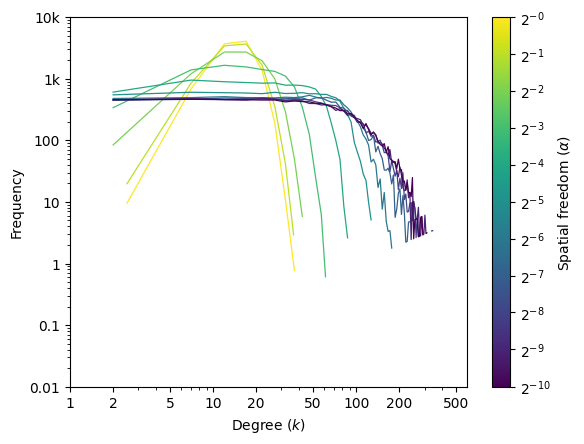

degree_distribution for layer L2 (4700) across alpha


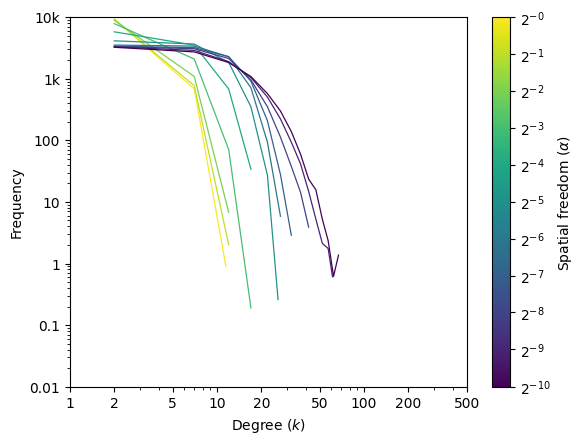

degree_distribution for layer L3 (326) across alpha


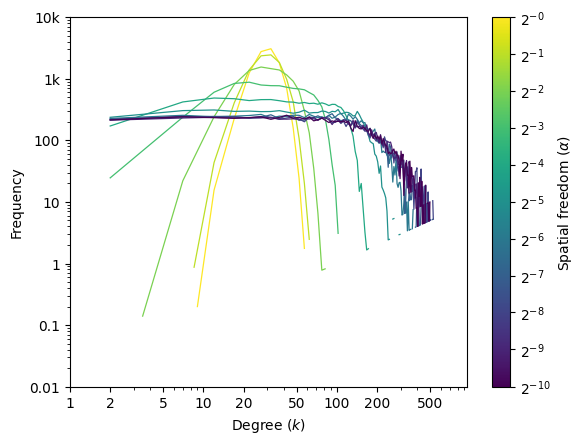

degree_distribution for layer L4 (7962) across alpha


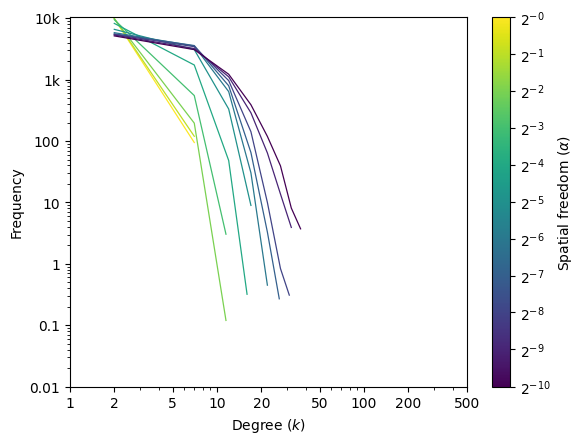

degree_distribution for layer L5 (5817) across alpha


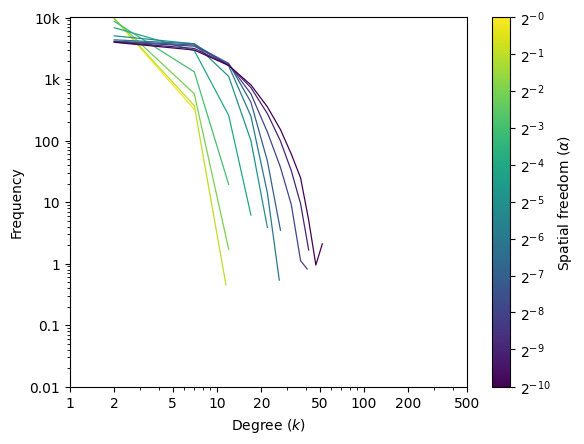

In [28]:
yticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
ytick_labels = ["0.01", "0.1", "1", "10", "100", "1k", "10k"]
xticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]

for layer_idx, layer_label in enumerate(layer_labels):
    print(
        f"degree_distribution for layer "
        f"{layer_label} ({layer_sizes[layer_idx]}) across alpha"
    )

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        x, y, se = rebin_degree_distribution(
            k,
            freq,
            se,
            bin_width=5,
        )

        lower = y - se
        upper = y + se

        y[y <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=0.9,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{-{j}}}$"
        for j in range(0, 11)
    ])

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    ax.set_ylim(bottom=1)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([str(t) for t in xticks])
    ax.set_yticklabels(ytick_labels)

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha_log_binned_5.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution by layer (alpha=1.0)


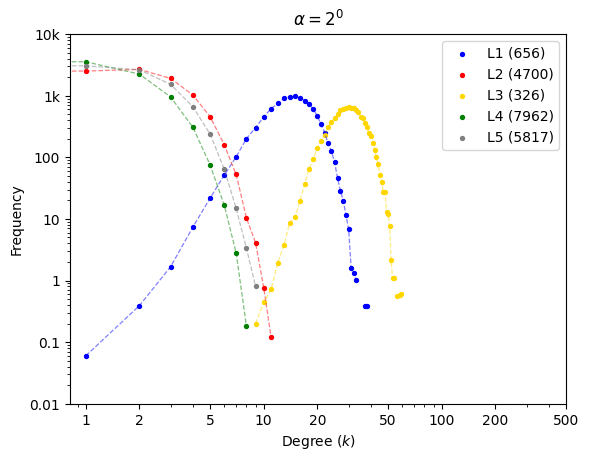

degree_distribution by layer (alpha=0.5)


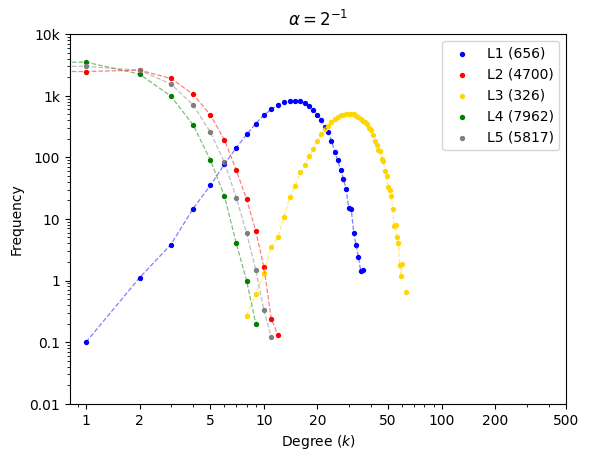

degree_distribution by layer (alpha=0.25)


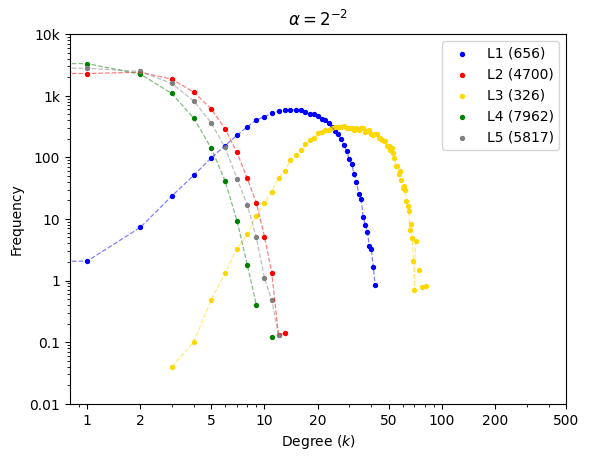

degree_distribution by layer (alpha=0.125)


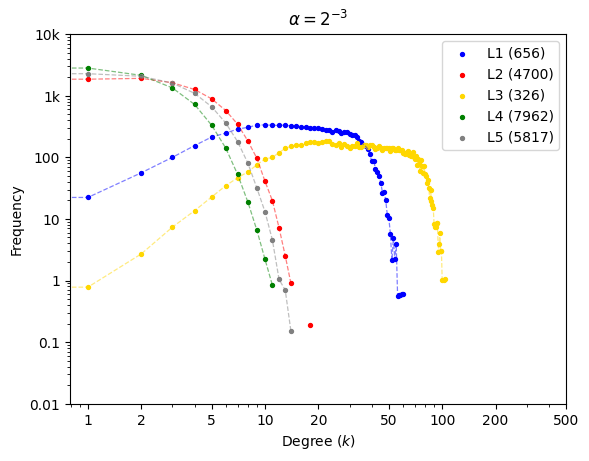

degree_distribution by layer (alpha=0.0625)


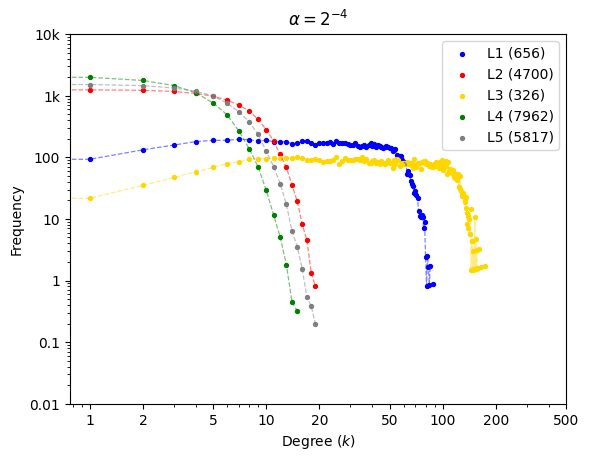

degree_distribution by layer (alpha=0.03125)


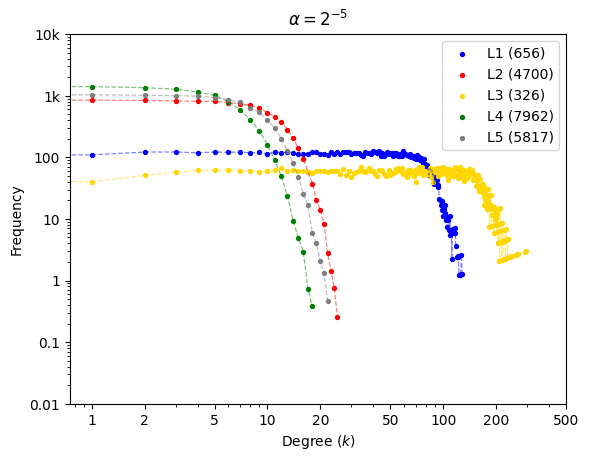

degree_distribution by layer (alpha=0.015625)


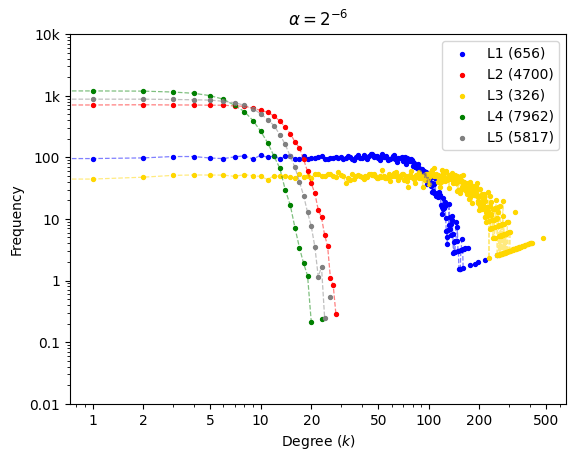

degree_distribution by layer (alpha=0.0078125)


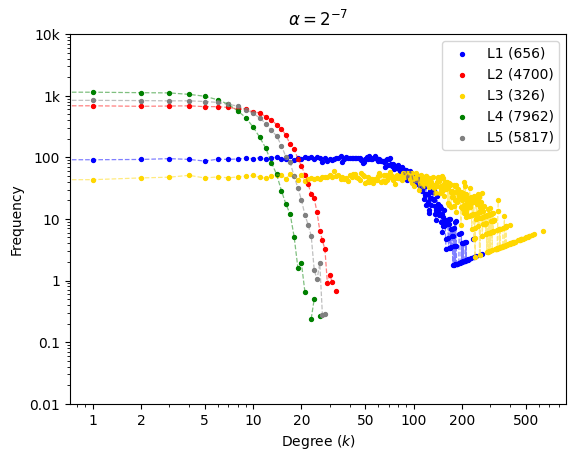

degree_distribution by layer (alpha=0.00390625)


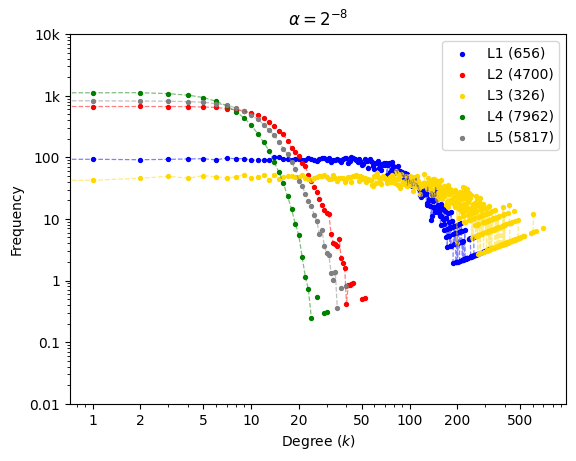

degree_distribution by layer (alpha=0.001953125)


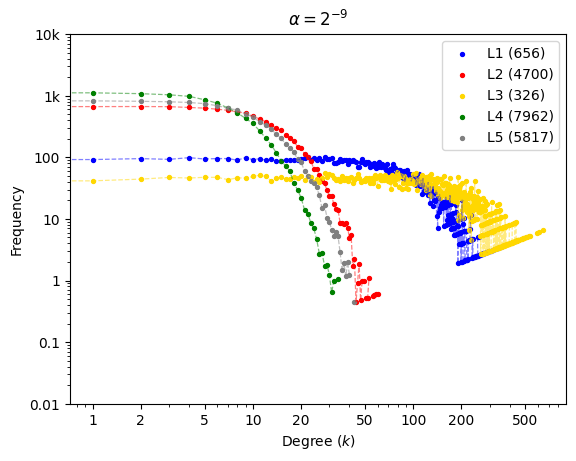

degree_distribution by layer (alpha=0.0009765625)


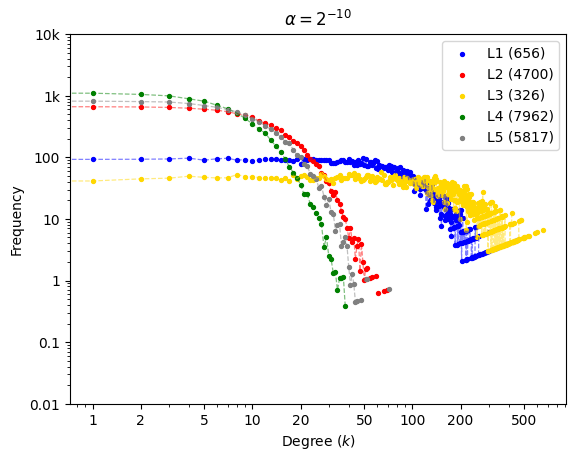

In [29]:
yticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
ytick_labels = ["0.01", "0.1", "1", "10", "100", "1k", "10k"]
xticks = [1, 2, 5, 10, 20, 50, 100, 200, 500]

for alpha_idx, alpha in enumerate(alphas):

    print(
        f"degree_distribution by layer "
        f"(alpha={alpha})"
    )

    fig, ax = plt.subplots()

    deg_dists_layers = results[alpha][
        PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
    ]

    for layer_idx, layer_label in enumerate(
        layer_labels
    ):

        dist = deg_dists_layers[layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        se = dist[:, 3].astype(float)

        lower = freq - se
        upper = freq + se

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        ax.plot(
            k,
            freq,
            color=layer_colors[layer_idx],
            linestyle="--",
            linewidth=0.9,
            alpha=0.5,
        )

        ax.scatter(
            k,
            freq,
            color=layer_colors[layer_idx],
            s=8,
            label=(
                f"{layer_label} "
                f"({layer_sizes[layer_idx]})"
            ),
        )

        """ax.plot(
            k,
            freq,
            color=layer_colors[layer_idx],
            linestyle=linestyles[
                layer_idx % len(linestyles)
            ],
            label=f"{layer_label}"
        )

        ax.fill_between(
            k,
            lower,
            upper,
            color=layer_colors[layer_idx],
            alpha=0.15,
        )"""

    ax.set_xscale("log")
    ax.set_yscale("log")
    #ax.set_xlim(1, plt.ylim()[1])
    #ax.set_ylim(1, plt.ylim()[1])

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([str(t) for t in xticks])
    ax.set_yticklabels(ytick_labels)

    ax.set_xlabel(r"Degree ($\mathit{k}$)")
    ax.set_ylabel("Frequency")

    ax.legend()

    exponent = -alpha_idx
    ax.set_title(
        rf"$\alpha = 2^{{{exponent:g}}}$"
    )

    plt.savefig(
        plot_dir /
        f"degree_distribution_layers_alpha_2^{exponent:g}.png",
        bbox_inches="tight",
    )

    plt.show()

### Mean/median degree per layer

In [30]:
def weighted_mean_from_distribution(k, freq):
    mask = np.isfinite(k) & np.isfinite(freq) & (freq > 0)
    k = k[mask]
    freq = freq[mask]

    return np.sum(k * freq) / np.sum(freq)


def weighted_median_from_distribution(k, freq):
    mask = np.isfinite(k) & np.isfinite(freq) & (freq > 0)
    k = k[mask]
    freq = freq[mask]

    order = np.argsort(k)
    k = k[order]
    freq = freq[order]

    cdf = np.cumsum(freq) / np.sum(freq)

    return k[np.searchsorted(cdf, 0.5)]

mean degree for layer L1 across alpha


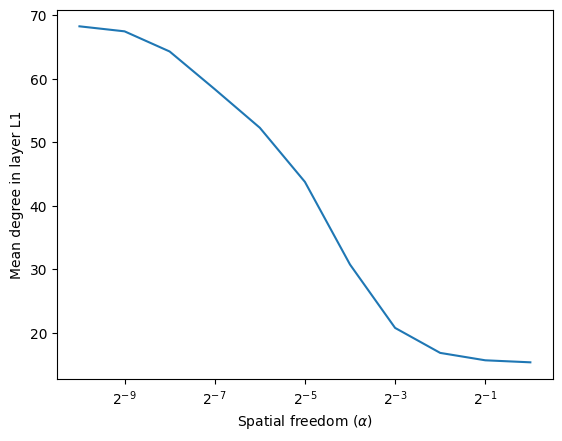

mean degree for layer L2 across alpha


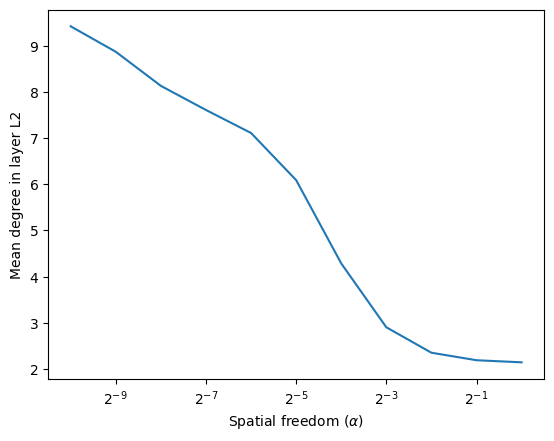

mean degree for layer L3 across alpha


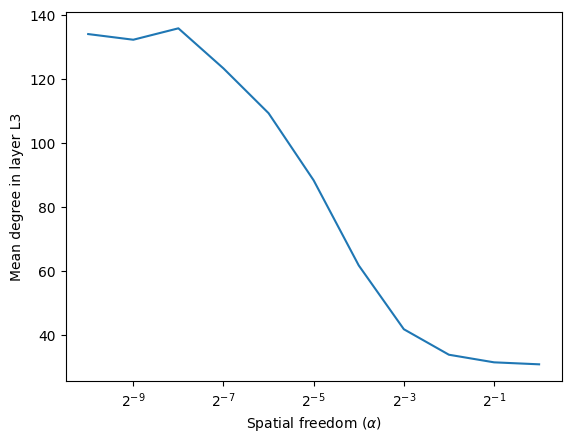

mean degree for layer L4 across alpha


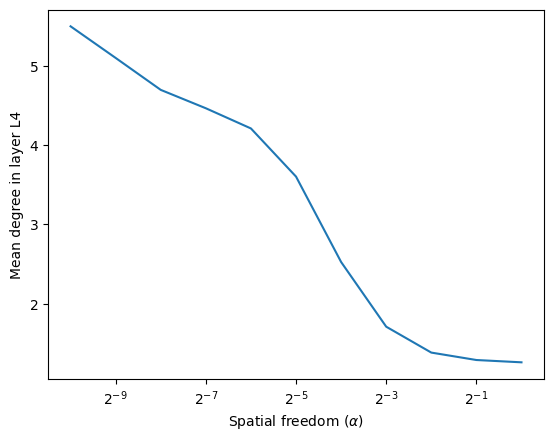

mean degree for layer L5 across alpha


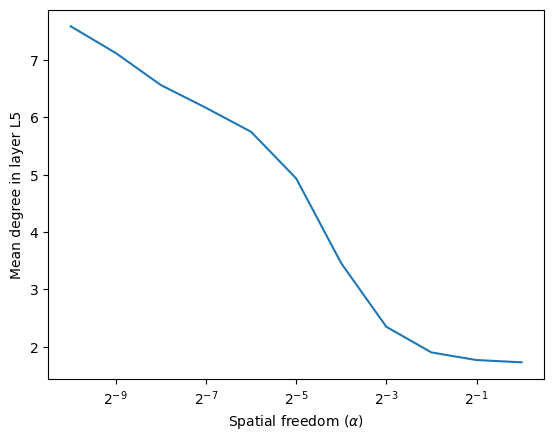

In [31]:
for layer_idx, layer_label in enumerate(layer_labels):
    print(f"mean degree for layer {layer_label} across alpha")

    mean_degrees = []

    for alpha in alphas:
        dist = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ][layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)

        mean_degrees.append(
            weighted_mean_from_distribution(k, freq)
        )

    fig, ax = plt.subplots()

    ax.plot(
        alphas,
        mean_degrees,
        linewidth=1.5,
    )

    ax.set_xscale("log", base=2)
    ax.set_xlabel(alpha_label)
    ax.set_ylabel(rf"Mean degree in layer {layer_label}")

    plt.savefig(
        plot_dir / f"mean_degree_layer_{layer_label}_vs_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

median degree for layer L1 across alpha


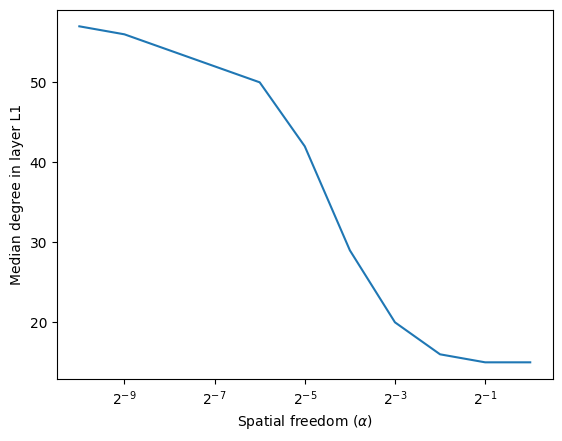

median degree for layer L2 across alpha


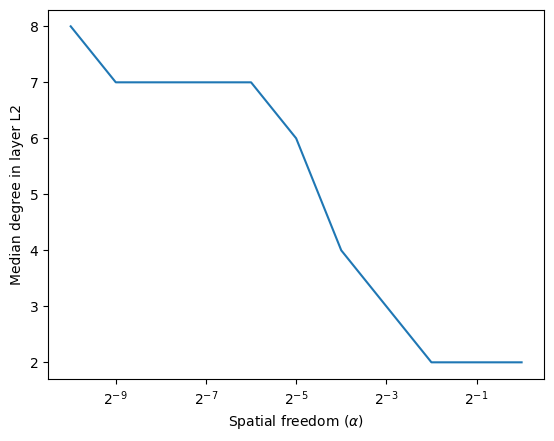

median degree for layer L3 across alpha


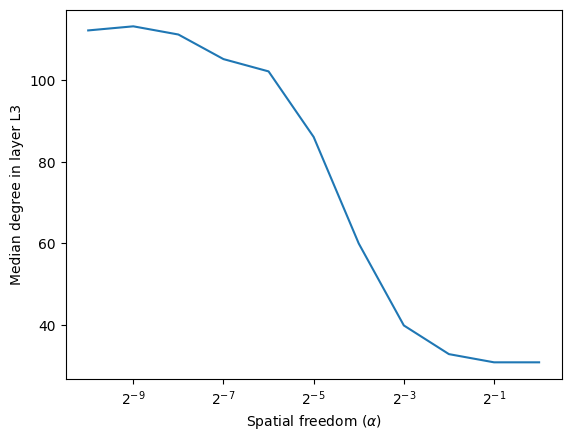

median degree for layer L4 across alpha


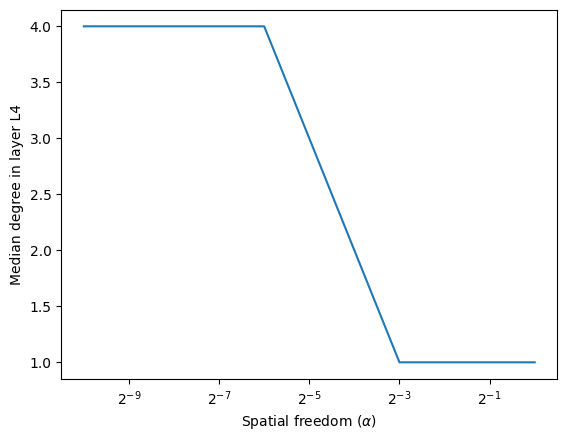

median degree for layer L5 across alpha


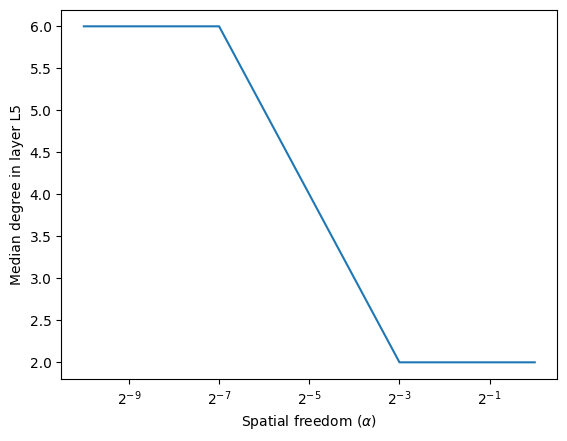

In [32]:
for layer_idx, layer_label in enumerate(layer_labels):
    print(f"median degree for layer {layer_label} across alpha")

    median_degrees = []

    for alpha in alphas:
        dist = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ][layer_idx]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)

        median_degrees.append(
            weighted_median_from_distribution(k, freq)
        )

    fig, ax = plt.subplots()

    ax.plot(
        alphas,
        median_degrees,
        linewidth=1.5,
    )

    ax.set_xscale("log", base=2)
    ax.set_xlabel(alpha_label)
    ax.set_ylabel(rf"Median degree in layer {layer_label}")

    plt.savefig(
        plot_dir / f"median_degree_layer_{layer_label}_vs_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

### Triangle dimensions

1d triangles


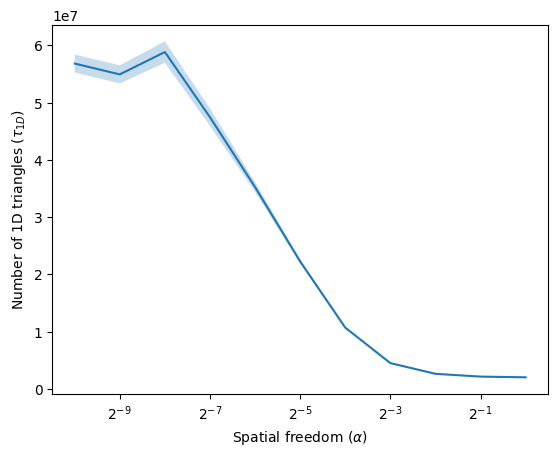

2d triangles


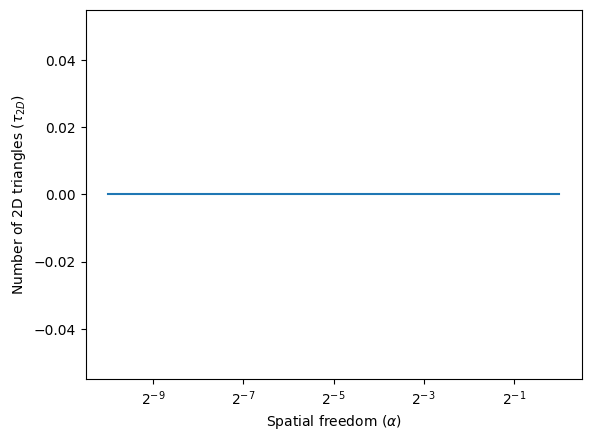

3d triangles


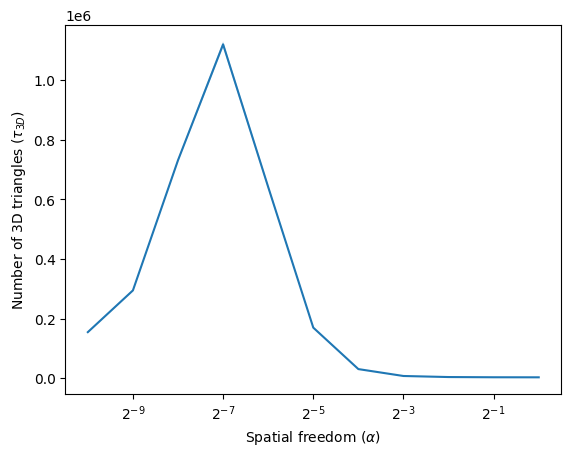

In [33]:
dimension_labels = [
    r"Number of 1D triangles ($\tau_{1D}$)",
    r"Number of 2D triangles ($\tau_{2D}$)",
    r"Number of 3D triangles ($\tau_{3D}$)",
]

dimension_names = ["1d", "2d", "3d"]

for dim_idx, (dim_label, dim_name) in enumerate(
    zip(dimension_labels, dimension_names)
):
    print(f"{dimension_names[dim_idx]} triangles")
    fig, ax = plt.subplots()

    means = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][0][dim_idx]
        for a in alphas
    ])

    ses = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][2][dim_idx]
        for a in alphas
    ])

    ax.plot(
        alphas,
        means,
    )

    ax.fill_between(
        alphas,
        means - ses,
        means + ses,
        alpha=0.25,
    )

    ax.set_xscale("log", base=2)
    ax.set_xlabel(alpha_label)
    ax.set_ylabel(dim_label)

    plt.savefig(
        plot_dir / f"triangles_{dim_name}_vs_alpha_se_log.png",
        bbox_inches="tight",
    )

    plt.show()

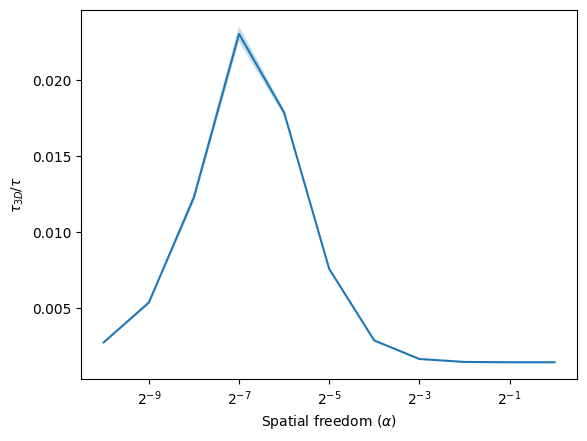

In [34]:
fig, ax = plt.subplots()

ratio_means = []
ratio_ses = []

for alpha in alphas:

    mean_dims, std_dims, se_dims = results[alpha][
        PropertyEnum.TRIANGLE_DIMENSIONS
    ]

    tau_1d, tau_2d, tau_3d = mean_dims
    se_1d, se_2d, se_3d = se_dims

    tau_total = tau_1d + tau_2d + tau_3d
    se_total = se_1d + se_2d + se_3d

    if tau_total > 0:
        ratio_mean = tau_3d / tau_total

        ratio_se = (
            (tau_3d + se_3d) / (tau_total + se_total)
            - ratio_mean
        )

        ratio_means.append(ratio_mean)
        ratio_ses.append(abs(ratio_se))
    else:
        ratio_means.append(np.nan)
        ratio_ses.append(np.nan)

ratio_means = np.array(ratio_means)
ratio_ses = np.array(ratio_ses)

ax.plot(
    alphas,
    ratio_means,
)

ax.fill_between(
    alphas,
    ratio_means - ratio_ses,
    ratio_means + ratio_ses,
    alpha=0.25,
)

ax.set_xscale("log", base=2)
ax.set_xlabel(alpha_label)
ax.set_ylabel(r"$\tau_{3D}/\tau$")

plt.savefig(
    plot_dir / "triangle_3d_fraction_vs_alpha.png",
    bbox_inches="tight",
)

plt.show()

1D, 3D, and 1D+3D triangles


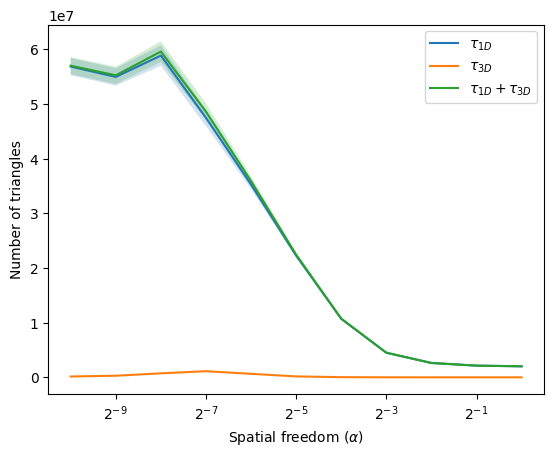

In [35]:
print("1D, 3D, and 1D+3D triangles")

fig, ax = plt.subplots()

triangle_specs = [
    ("1D", 0, r"$\tau_{1D}$"),
    ("3D", 2, r"$\tau_{3D}$"),
]

for name, dim_idx, label in triangle_specs:
    means = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][0][dim_idx]
        for a in alphas
    ])

    ses = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][2][dim_idx]
        for a in alphas
    ])

    ax.plot(
        alphas,
        means,
        label=label,
    )

    ax.fill_between(
        alphas,
        means - ses,
        means + ses,
        alpha=0.20,
    )

# 1D + 3D
means_1d = np.array([
    results[a][PropertyEnum.TRIANGLE_DIMENSIONS][0][0]
    for a in alphas
])

means_3d = np.array([
    results[a][PropertyEnum.TRIANGLE_DIMENSIONS][0][2]
    for a in alphas
])

ses_1d = np.array([
    results[a][PropertyEnum.TRIANGLE_DIMENSIONS][2][0]
    for a in alphas
])

ses_3d = np.array([
    results[a][PropertyEnum.TRIANGLE_DIMENSIONS][2][2]
    for a in alphas
])

means_sum = means_1d + means_3d
ses_sum = np.sqrt(ses_1d**2 + ses_3d**2)

ax.plot(
    alphas,
    means_sum,
    label=r"$\tau_{1D} + \tau_{3D}$",
)

ax.fill_between(
    alphas,
    means_sum - ses_sum,
    means_sum + ses_sum,
    alpha=0.20,
)

ax.set_xscale("log", base=2)
ax.set_xlabel(alpha_label)
ax.set_ylabel("Number of triangles")
ax.legend()

plt.savefig(
    plot_dir / "triangles_1d_3d_sum_vs_alpha_se_log.png",
    bbox_inches="tight",
)

plt.show()

### Closure plots against mobility (average proportional alter distance)
TODO: Also plot against multiplexity

average_local_clustering vs alpha


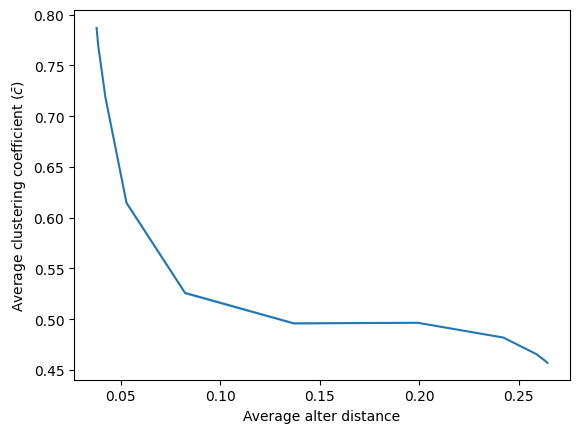

In [36]:
prop = PropertyEnum.AVERAGE_LOCAL_CLUSTERING
print(f"{prop.name.lower()} vs alpha")

means = np.array([results[a][prop][0] for a in alphas])
ses = np.array([results[a][prop][2] for a in alphas])

fig, ax = plt.subplots()

ax.plot(avg_prop_alter_dist, means)

ax.fill_between(
    avg_prop_alter_dist,
    means - ses, #stds,
    means + ses, #stds,
    alpha=0.25,
)

ax.set_xlabel("Average alter distance")

label = prop_labels.get(prop, prop.name.lower())
ax.set_ylabel(label)

plt.savefig(
    plot_dir / f"{prop.name.lower()}_vs_avg_alter_dist.png",
    bbox_inches="tight",
)

plt.show()

average_local_clustering vs alpha


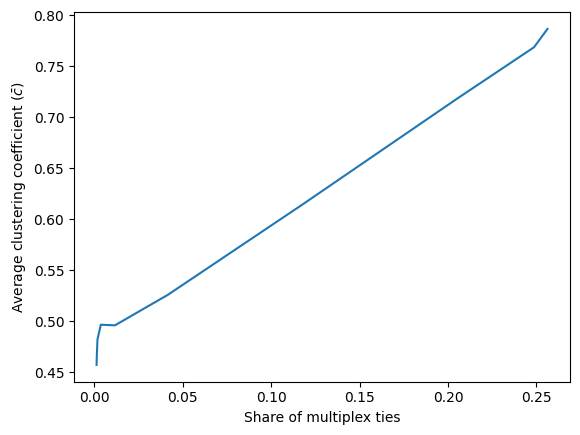

In [37]:
prop = PropertyEnum.AVERAGE_LOCAL_CLUSTERING
print(f"{prop.name.lower()} vs alpha")

means = np.array([results[a][prop][0] for a in alphas])
ses = np.array([results[a][prop][2] for a in alphas])

fig, ax = plt.subplots()

ax.plot(share_multiplex_ties_list, means)

"""ax.fill_between(
    avg_prop_alter_dist,
    means - ses, #stds,
    means + ses, #stds,
    alpha=0.25,
)"""

ax.set_xlabel("Share of multiplex ties")

label = prop_labels.get(prop, prop.name.lower())
ax.set_ylabel(label)

plt.savefig(
    plot_dir / f"{prop.name.lower()}_vs_share_multiplex_ties.png",
    bbox_inches="tight",
)

plt.show()

1D, 3D, and 1D+3D triangles


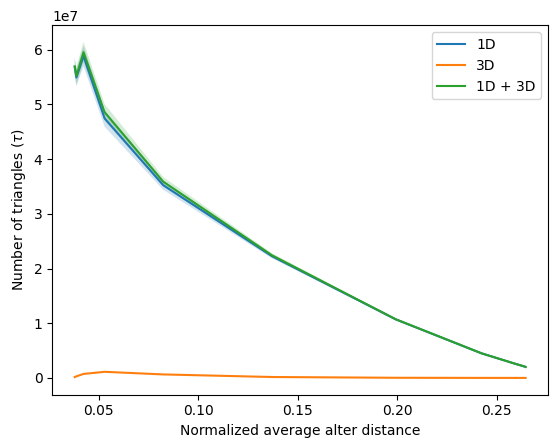

In [38]:
print("1D, 3D, and 1D+3D triangles")

fig, ax = plt.subplots()

triangle_specs = [
    ("1D", 0, "1D"),
    ("3D", 2, "3D"),
]

for name, dim_idx, label in triangle_specs:
    means = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][0][dim_idx]
        for a in alphas
    ])

    ses = np.array([
        results[a][PropertyEnum.TRIANGLE_DIMENSIONS][2][dim_idx]
        for a in alphas
    ])

    ax.plot(
        avg_prop_alter_dist,
        means,
        label=label,
    )

    ax.fill_between(
        avg_prop_alter_dist,
        means - ses,
        means + ses,
        alpha=0.20,
    )

# 1D + 3D
means_1d = np.array([
    results[a][PropertyEnum.TRIANGLE_DIMENSIONS][0][0]
    for a in alphas
])

means_3d = np.array([
    results[a][PropertyEnum.TRIANGLE_DIMENSIONS][0][2]
    for a in alphas
])

ses_1d = np.array([
    results[a][PropertyEnum.TRIANGLE_DIMENSIONS][2][0]
    for a in alphas
])

ses_3d = np.array([
    results[a][PropertyEnum.TRIANGLE_DIMENSIONS][2][2]
    for a in alphas
])

means_sum = means_1d + means_3d
ses_sum = np.sqrt(ses_1d**2 + ses_3d**2)

ax.plot(
    avg_prop_alter_dist,
    means_sum,
    label="1D + 3D",
)

ax.fill_between(
    avg_prop_alter_dist,
    means_sum - ses_sum,
    means_sum + ses_sum,
    alpha=0.20,
)

ax.set_xlabel("Normalized average alter distance")
ax.set_ylabel(r"Number of triangles ($\tau$)")
ax.legend()

plt.savefig(
    plot_dir / "triangles_1d_3d_sum_vs_avg_prop_alter_dist_se.png",
    bbox_inches="tight",
)

plt.show()

3D triangle ratio


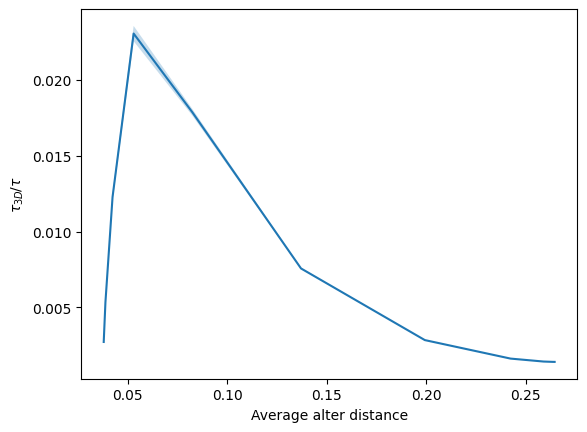

In [39]:
print("3D triangle ratio")

fig, ax = plt.subplots()

ratio_means = []
ratio_ses = []

for alpha in alphas:

    mean_dims, std_dims, se_dims = results[alpha][
        PropertyEnum.TRIANGLE_DIMENSIONS
    ]

    tau_1d, tau_2d, tau_3d = mean_dims
    se_1d, se_2d, se_3d = se_dims

    tau_total = tau_1d + tau_2d + tau_3d
    se_total = se_1d + se_2d + se_3d

    if tau_total > 0:
        ratio_mean = tau_3d / tau_total

        ratio_se = (
            (tau_3d + se_3d) / (tau_total + se_total)
            - ratio_mean
        )

        ratio_means.append(ratio_mean)
        ratio_ses.append(abs(ratio_se))
    else:
        ratio_means.append(np.nan)
        ratio_ses.append(np.nan)

ratio_means = np.array(ratio_means)
ratio_ses = np.array(ratio_ses)

ax.plot(
    avg_prop_alter_dist,
    ratio_means,
)

ax.fill_between(
    avg_prop_alter_dist,
    ratio_means - ratio_ses,
    ratio_means + ratio_ses,
    alpha=0.25,
)

ax.set_xlabel("Average alter distance")
ax.set_ylabel(r"$\tau_{3D}/\tau$")

plt.savefig(
    plot_dir / "triangle_3d_fraction_vs_avg_alter_dist.png",
    bbox_inches="tight",
)

plt.show()

3D triangle ratio


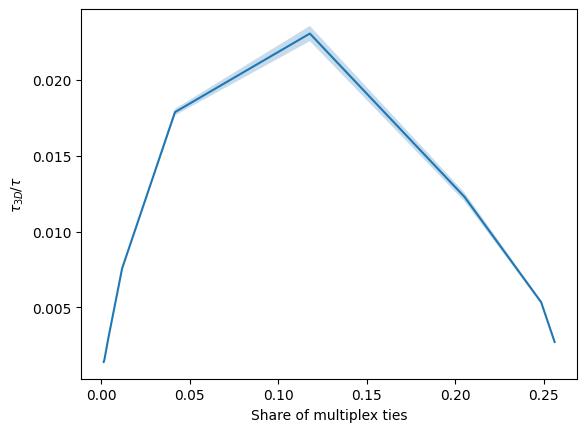

In [40]:
print("3D triangle ratio")

fig, ax = plt.subplots()

ratio_means = []
ratio_ses = []

for alpha in alphas:

    mean_dims, std_dims, se_dims = results[alpha][
        PropertyEnum.TRIANGLE_DIMENSIONS
    ]

    tau_1d, tau_2d, tau_3d = mean_dims
    se_1d, se_2d, se_3d = se_dims

    tau_total = tau_1d + tau_2d + tau_3d
    se_total = se_1d + se_2d + se_3d

    if tau_total > 0:
        ratio_mean = tau_3d / tau_total

        ratio_se = (
            (tau_3d + se_3d) / (tau_total + se_total)
            - ratio_mean
        )

        ratio_means.append(ratio_mean)
        ratio_ses.append(abs(ratio_se))
    else:
        ratio_means.append(np.nan)
        ratio_ses.append(np.nan)

ratio_means = np.array(ratio_means)
ratio_ses = np.array(ratio_ses)

ax.plot(
    share_multiplex_ties_list,
    ratio_means,
)

ax.fill_between(
    share_multiplex_ties_list,
    ratio_means - ratio_ses,
    ratio_means + ratio_ses,
    alpha=0.25,
)

ax.set_xlabel("Share of multiplex ties")
ax.set_ylabel(r"$\tau_{3D}/\tau$")

plt.savefig(
    plot_dir / "triangle_3d_fraction_vs_share_multiplex_ties.png",
    bbox_inches="tight",
)

plt.show()

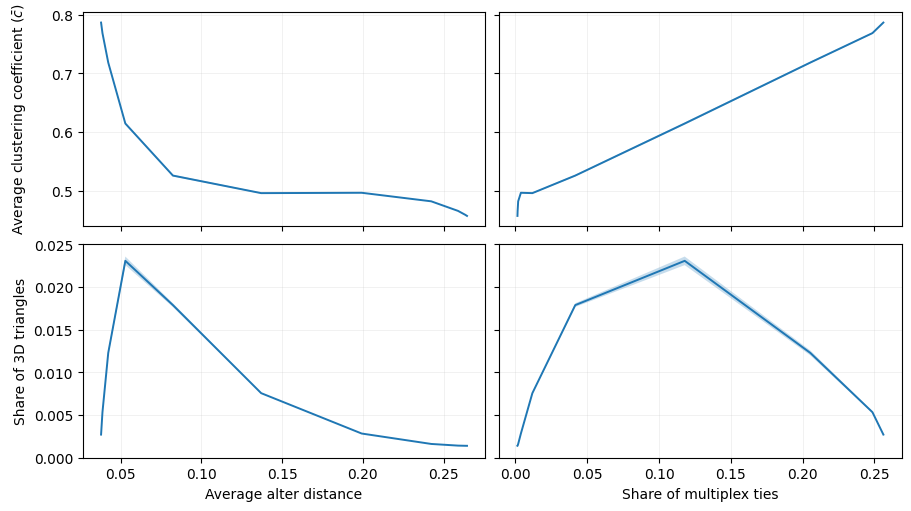

In [41]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------------
# Prepare the shared data once
# ------------------------------------------------------------------

avg_alter_dist = np.asarray(
    avg_prop_alter_dist,
    dtype=float,
)

multiplexity = np.asarray(
    share_multiplex_ties_list,
    dtype=float,
)

# Average local clustering
clustering_prop = PropertyEnum.AVERAGE_LOCAL_CLUSTERING

clustering_means = np.array([
    results[alpha][clustering_prop][0]
    for alpha in alphas
], dtype=float)

clustering_ses = np.array([
    results[alpha][clustering_prop][2]
    for alpha in alphas
], dtype=float)


# 3D triangle ratio
ratio_means = []
ratio_ses = []

for alpha in alphas:
    mean_dims, std_dims, se_dims = results[alpha][
        PropertyEnum.TRIANGLE_DIMENSIONS
    ]

    tau_1d, tau_2d, tau_3d = mean_dims
    se_1d, se_2d, se_3d = se_dims

    tau_total = tau_1d + tau_2d + tau_3d
    se_total = se_1d + se_2d + se_3d

    if tau_total > 0:
        ratio_mean = tau_3d / tau_total

        # Approximate propagated uncertainty
        ratio_se = abs(
            (tau_3d + se_3d) / (tau_total + se_total)
            - ratio_mean
        )
    else:
        ratio_mean = np.nan
        ratio_se = np.nan

    ratio_means.append(ratio_mean)
    ratio_ses.append(ratio_se)

ratio_means = np.asarray(ratio_means, dtype=float)
ratio_ses = np.asarray(ratio_ses, dtype=float)


# ------------------------------------------------------------------
# Create 2 x 2 tiled figure
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(9, 5),
    sharex="col",
    sharey="row",
    constrained_layout=True,
)

ax_tl = axes[0, 0]
ax_tr = axes[0, 1]
ax_bl = axes[1, 0]
ax_br = axes[1, 1]


# ------------------------------------------------------------------
# Top left: clustering vs average alter distance
# ------------------------------------------------------------------

ax_tl.plot(
    avg_alter_dist,
    clustering_means,
    linewidth=1.4,
)

ax_tl.fill_between(
    avg_alter_dist,
    clustering_means - clustering_ses,
    clustering_means + clustering_ses,
    alpha=0.25,
)

ax_tl.set_ylabel(
    prop_labels.get(
        clustering_prop,
        clustering_prop.name.lower(),
    )
)



# ------------------------------------------------------------------
# Top right: clustering vs multiplexity
# ------------------------------------------------------------------

ax_tr.plot(
    multiplexity,
    clustering_means,
    linewidth=1.4,
)

ax_tr.fill_between(
    multiplexity,
    clustering_means - clustering_ses,
    clustering_means + clustering_ses,
    alpha=0.25,
)



# ------------------------------------------------------------------
# Bottom left: 3D triangle ratio vs average alter distance
# ------------------------------------------------------------------

ax_bl.plot(
    avg_alter_dist,
    ratio_means,
    linewidth=1.4,
)

ax_bl.fill_between(
    avg_alter_dist,
    ratio_means - ratio_ses,
    ratio_means + ratio_ses,
    alpha=0.25,
)

ax_bl.set_xlabel("Average alter distance")
ax_bl.set_ylabel(r"Share of 3D triangles")




# ------------------------------------------------------------------
# Bottom right: 3D triangle ratio vs multiplexity
# ------------------------------------------------------------------

ax_br.plot(
    multiplexity,
    ratio_means,
    linewidth=1.4,
)

ax_br.fill_between(
    multiplexity,
    ratio_means - ratio_ses,
    ratio_means + ratio_ses,
    alpha=0.25,
)

ax_br.set_xlabel("Share of multiplex ties")




# ------------------------------------------------------------------
# Optional formatting
# ------------------------------------------------------------------

for ax in axes.flat:
    ax.grid(
        alpha=0.2,
        linewidth=0.6,
    )

# Ratios should remain between 0 and 1
ax_bl.set_ylim(0, 0.025)

fig.align_ylabels([ax_tl, ax_bl])

fig.savefig(
    plot_dir / "clustering_triangle_ratio_vs_mobility_overlap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)